In [6]:
!pip install yfinance

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.9 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=bcaf8ec1d926b4414c4fff1a9254bab88f4318c8750ada8d48cc35da68ad454f
  Stored in directory: /Users/rozarychlik/Library/Caches/pip/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1


--- Collecting Data & Assessing KPIs ---

[AAPL] Basic Statistics:
count    251.000000
mean     137.450292
std       14.370089
min      113.334129
25%      125.404476
50%      137.880234
75%      145.462624
max      176.459732
Name: Close, dtype: float64

[MSFT] Basic Statistics:
count    251.000000
mean     260.700086
std       24.373470
min      208.183899
25%      240.121033
50%      257.824310
75%      280.390701
max      323.160767
Name: Close, dtype: float64

[AMZN] Basic Statistics:
count    250.000000
mean     121.372800
std       18.900946
min       83.120003
25%      102.254999
50%      126.830002
75%      135.360001
max      154.070007
Name: Close, dtype: float64

[TSLA] Basic Statistics:
count    252.000000
mean      96.115857
std       55.759589
min       24.081333
25%       49.915834
50%       77.609665
75%      140.344994
max      231.666672
Name: Close, dtype: float64

[NVDA] Basic Statistics:
count    251.000000
mean       4.331109
std        0.618550
min        3.1729

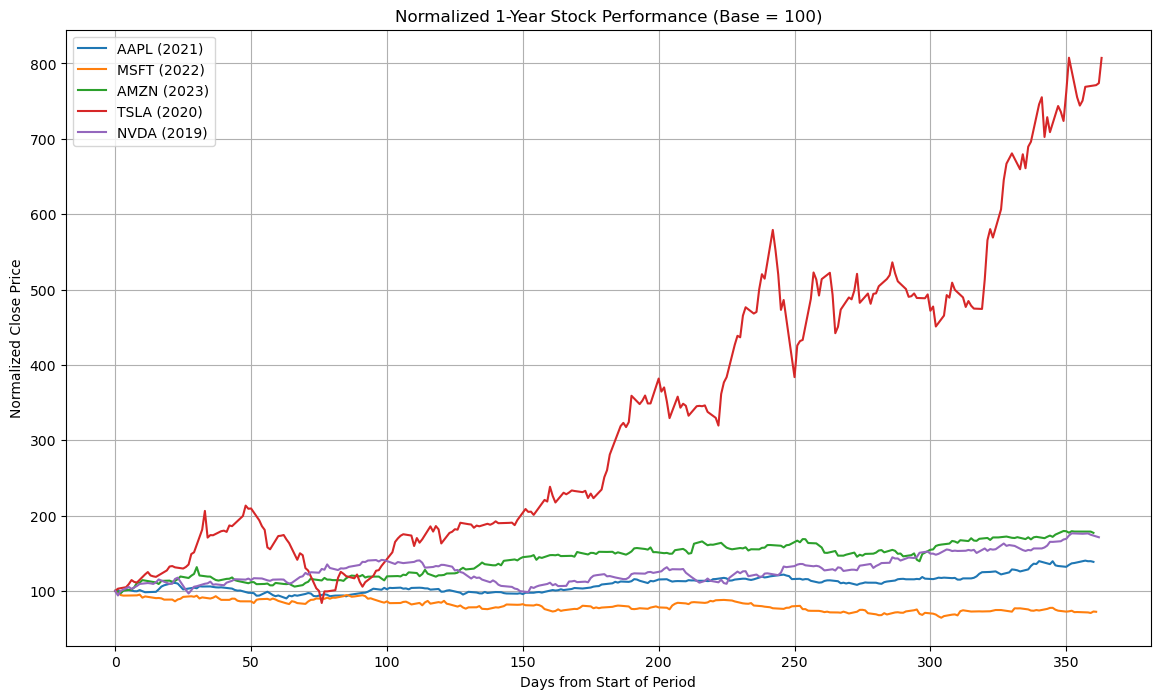

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

companies = {
    "AAPL": {"start": "2021-01-01", "end": "2021-12-31"},
    "MSFT": {"start": "2022-01-01", "end": "2022-12-31"},
    "AMZN": {"start": "2023-01-01", "end": "2023-12-31"},
    "TSLA": {"start": "2020-01-01", "end": "2020-12-31"},
    "NVDA": {"start": "2019-01-01", "end": "2019-12-31"} 
}

data_frames = {}
kpi_results = []

print("--- Collecting Data & Assessing KPIs ---")

for ticker, dates in companies.items():
    df = yf.download(ticker, start=dates["start"], end=dates["end"], progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    df.reset_index(inplace=True)
    data_frames[ticker] = df
    
    print(f"\n[{ticker}] Basic Statistics:")
    print(df['Close'].describe())
    
    # KPI CALCULATIONS 
    
    # (a) Completeness:
    missing_values = df['Close'].isnull().sum()
    completeness = 100 - (missing_values / len(df) * 100)
    
    # (b) Latency:
    last_date = df['Date'].max()
    latency_days = (datetime.now() - last_date).days
    
    # (c) Accuracy:
    accurate_rows = df[(df['High'] >= df['Low']) & (df['Close'] > 0)]
    accuracy = (len(accurate_rows) / len(df)) * 100
    
    # (d) Consistency:
    is_float = pd.api.types.is_float_dtype(df['Close'])
    unique_dates = df['Date'].is_unique
    consistency = "High" if (is_float and unique_dates) else "Low"
    
    kpi_results.append({
        "Ticker": ticker,
        "Period": f"{dates['start']} to {dates['end']}",
        "Completeness (%)": completeness,
        "Latency (Days)": latency_days,
        "Accuracy (%)": accuracy,
        "Consistency": consistency
    })

kpi_df = pd.DataFrame(kpi_results)
print("\n--- KPI Summary ---")
print(kpi_df.to_string(index=False))

# Visualization
plt.figure(figsize=(14, 8))

for ticker, df in data_frames.items():
    days_from_start = (df['Date'] - df['Date'].min()).dt.days
    normalized_price = (df['Close'] / df['Close'].iloc[0]) * 100
    
    plt.plot(days_from_start, normalized_price, label=f"{ticker} ({companies[ticker]['start'][:4]})")

plt.title('Normalized 1-Year Stock Performance (Base = 100)')
plt.xlabel('Days from Start of Period')
plt.ylabel('Normalized Close Price')
plt.legend()
plt.grid(True)
plt.show()